# 🎓 Datathon FIAP Fase 5 — Passos Mágicos
## Análise do Desenvolvimento Educacional e Predição de Risco de Defasagem

**Associação Passos Mágicos** — instrumento de transformação social por meio da educação para crianças e jovens em vulnerabilidade.

**Dataset:** Dados do desenvolvimento educacional dos anos **2022, 2023 e 2024**.

---

### Estrutura do Notebook
| # | Seção | Objetivo |
|---|-------|----------|
| 1 | Setup & Carregamento | Importações, caminhos, carga e inspeção dos dados |
| 2 | Limpeza & EDA | Responder às 11 perguntas de negócio com visualizações |
| 3 | Engenharia de Features | Criar variáveis derivadas para o modelo preditivo |
| 4 | Modelagem ML | Treinar, comparar e avaliar modelos preditivos |
| 5 | Interpretação | Feature importance, curvas ROC/PR, threshold otimizado |
| 6 | Exportação | Salvar artefatos e gerar planilha de validação para o app |

---
> **Diferencial desta abordagem:** Imputação por mediana + flags de ausência; features de risco compostas; LightGBM/GradientBoosting como modelos principais; otimização de threshold por F-beta (β=2) para priorizar recall na classe de risco.

In [32]:
# ─── 1. IMPORTAÇÕES ─────────────────────────────────────────────────────────
import os, re, sys, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dotenv import load_dotenv, find_dotenv

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, fbeta_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)


from lightgbm import LGBMClassifier


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

SEED    = 42
PALETTE = "Set2"
print("✅ Ambiente configurado.")

✅ Ambiente configurado.


In [33]:
# ─── 2. CONFIGURAÇÃO DE CAMINHOS E CARREGAMENTO ─────────────────────────────
import unicodedata
load_dotenv(find_dotenv())

DATA_PATH  = Path(os.getenv("DATA_PATH",  "dados/PEDE_PASSOS_DATASET_FIAP.xlsx"))
MODELS_DIR = Path(os.getenv("MODELS",     "modelo"))
PROC_DIR   = Path(os.getenv("PROCESSED",  "dados/processado"))

MODELS_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset   : {DATA_PATH}")
print(f"Modelos   : {MODELS_DIR}")
print(f"Processado: {PROC_DIR}")

# ─── Carregamento de múltiplas abas (uma por ano) ─────────────────────────────
def _norm_cols(df):
    """Normaliza nomes de colunas: minúsculas, sem acentos, espaços → underscore."""
    cols = []
    for c in df.columns.astype(str):
        c = ''.join(ch for ch in unicodedata.normalize('NFD', c)
                    if unicodedata.category(ch) != 'Mn')
        c = c.strip().lower()
        c = re.sub(r'[\s\-\.]+', '_', c)
        c = re.sub(r'[^a-z0-9_]', '', c)
        c = re.sub(r'_+', '_', c).strip('_')
        cols.append(c)
    df.columns = cols
    return df

planilhas = pd.read_excel(DATA_PATH, sheet_name=None)   # lê TODAS as abas
print(f"\nAbas encontradas: {list(planilhas.keys())}")

dfs = []
for sheet_name, sheet_df in planilhas.items():
    # Extrai ano dos dígitos do nome da aba: "PEDE2022" → 2022
    digitos = ''.join(filter(str.isdigit, sheet_name))
    ano = int(digitos[-4:]) if len(digitos) >= 4 else int(digitos)
    sheet_df = _norm_cols(sheet_df)
    sheet_df["ano_pede"] = ano          # ← índice temporal usado no split ML
    dfs.append(sheet_df)
    print(f"  {sheet_name:12s} → ano={ano}  shape={sheet_df.shape}")

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nShape final (todas as abas): {df_raw.shape}")
print(f"Anos disponíveis: {sorted(df_raw['ano_pede'].unique())}")

print(f"\nColunas ({len(df_raw.columns)}):")
print(df_raw.columns.tolist())

print("\nNulos (%) — somente colunas com dados ausentes:")
nulls = (df_raw.isnull().mean() * 100).sort_values(ascending=False)
print(nulls[nulls > 0].head(20).to_string())

print("\nEstatísticas descritivas dos principais indicadores:")
indicadores = [c for c in ["ian","ida","ieg","iaa","ips","ipp","ipv",
                            "inde_2022","inde_2023","inde_2024","mat","por","ing"]
               if c in df_raw.columns]
if indicadores:
    print(f"Indicadores encontrados: {indicadores}")
    display(df_raw[indicadores].describe().T)
else:
    candidatos = [c for c in df_raw.columns
                  if any(kw in c for kw in ["ian","ida","ieg","iaa","ips","ipp","ipv",
                                             "inde","mat","por","ing"])]
    print(f"⚠️  Indicadores padrão não encontrados. Candidatos: {candidatos}")
    print("\nTodas as colunas:")
    print(df_raw.columns.tolist())

Dataset   : dados\PEDE_PASSOS_DATASET_FIAP.xlsx
Modelos   : modelo
Processado: dados\processado

Abas encontradas: ['PEDE2022', 'PEDE2023', 'PEDE2024']
  PEDE2022     → ano=2022  shape=(860, 43)
  PEDE2023     → ano=2023  shape=(1014, 49)
  PEDE2024     → ano=2024  shape=(1156, 51)

Shape final (todas as abas): (3030, 63)
Anos disponíveis: [np.int64(2022), np.int64(2023), np.int64(2024)]

Colunas (63):
['ra', 'fase', 'turma', 'nome', 'ano_nasc', 'idade_22', 'genero', 'ano_ingresso', 'instituicao_de_ensino', 'pedra_20', 'pedra_21', 'pedra_22', 'inde_22', 'cg', 'cf', 'ct', 'n_av', 'avaliador1', 'rec_av1', 'avaliador2', 'rec_av2', 'avaliador3', 'rec_av3', 'avaliador4', 'rec_av4', 'iaa', 'ieg', 'ips', 'rec_psicologia', 'ida', 'matem', 'portug', 'ingles', 'indicado', 'atingiu_pv', 'ipv', 'ian', 'fase_ideal', 'defas', 'destaque_ieg', 'destaque_ida', 'destaque_ipv', 'ano_pede', 'inde_2023', 'pedra_2023', 'nome_anonimizado', 'data_de_nasc', 'idade', 'pedra_23', 'inde_23', 'ipp', 'mat', 'por', 

,count,mean,std,min,25%,50%,75%,max
ian,3030.0,7.179043,2.535266,2.500000,5.000000,5.000000,10.000000,10.0000
ida,2852.0,6.375964,1.956637,0.000000,5.100000,6.666667,7.833333,10.0000
ieg,2954.0,7.945696,2.152281,0.000000,7.300000,8.600000,9.400000,10.0000
iaa,2865.0,7.918225,2.626209,0.000000,7.900000,8.751000,9.500000,10.0020
ips,2859.0,6.287129,1.792491,2.500000,5.020000,7.500000,7.510000,10.0000
ipp,1992.0,7.555203,0.938990,2.500000,7.083333,7.500000,8.125000,10.0000
ipv,2852.0,7.545476,1.084347,2.500000,6.984000,7.583000,8.255000,10.0100
inde_2023,931.0,7.342309,0.901757,3.745542,6.724150,7.408033,7.996083,9.3712
mat,1988.0,6.314688,2.375754,0.000000,5.000000,6.500000,8.000000,10.0000
por,1987.0,6.478032,2.162505,0.000000,5.200000,6.800000,8.000000,10.0000


---
## 📊 Parte 1 — Análise Exploratória de Dados

> Cada sub-seção responde a **uma das 11 perguntas de negócio** do Datathon.
> As análises cobrem os anos de **2022, 2023 e 2024**.

Shape após limpeza: (3030, 63)


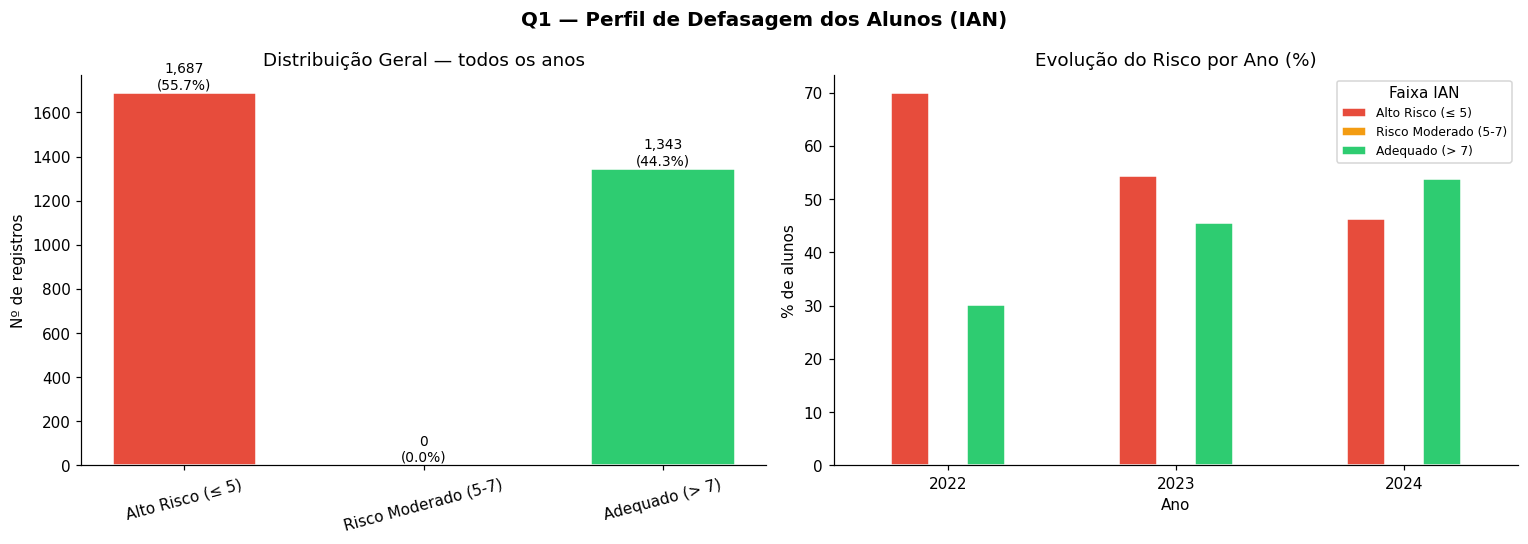


📌 55.7% dos registros estão em ALTO RISCO de defasagem (IAN ≤ 5)
faixa_ian
Alto Risco (≤ 5)        1687
Risco Moderado (5-7)       0
Adequado (> 7)          1343


In [34]:
# ─── LIMPEZA BASE (para EDA) ──────────────────────────────────────────────────
sys.path.insert(0, ".")
from utils_pm import limpar_base

df = limpar_base(df_raw)
print("Shape após limpeza:", df.shape)

# ─── Q1: Perfil de Defasagem (IAN) ──────────────────────────────────────────
# IAN <= 5 = Alto risco | 5 < IAN <= 7 = Moderado | IAN > 7 = Adequado
if "ian" in df.columns:
    def classificar_ian(s):
        return pd.cut(s, bins=[-0.01, 5.0, 7.0, 10.1],
                      labels=["Alto Risco (≤ 5)", "Risco Moderado (5-7)", "Adequado (> 7)"])

    df["faixa_ian"] = classificar_ian(df["ian"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Q1 — Perfil de Defasagem dos Alunos (IAN)", fontweight="bold", fontsize=13)
    cores = ["#E74C3C", "#F39C12", "#2ECC71"]

    counts = df["faixa_ian"].value_counts().sort_index()
    bars = axes[0].bar(counts.index.astype(str), counts.values, color=cores, edgecolor="white", width=0.6)
    for b, v in zip(bars, counts.values):
        axes[0].text(b.get_x() + b.get_width()/2, b.get_height()+5,
                     f"{v:,}\n({v/counts.sum()*100:.1f}%)", ha="center", va="bottom", fontsize=9)
    axes[0].set_title("Distribuição Geral — todos os anos")
    axes[0].set_ylabel("Nº de registros")
    axes[0].tick_params(axis="x", rotation=15)

    if "ano_pede" in df.columns:
        ev = (df.groupby(["ano_pede", "faixa_ian"]).size()
                .unstack(fill_value=0)
                .apply(lambda x: x/x.sum()*100, axis=1))
        ev.plot(kind="bar", ax=axes[1], color=cores, edgecolor="white", rot=0)
        axes[1].set_title("Evolução do Risco por Ano (%)")
        axes[1].set_xlabel("Ano")
        axes[1].set_ylabel("% de alunos")
        axes[1].legend(title="Faixa IAN", fontsize=8, loc="upper right")

    plt.tight_layout()
    plt.savefig(PROC_DIR / "q1_ian_defasagem.png", bbox_inches="tight")
    plt.show()

    pct = (df["faixa_ian"] == "Alto Risco (≤ 5)").mean()
    print(f"\n📌 {pct:.1%} dos registros estão em ALTO RISCO de defasagem (IAN ≤ 5)")
    print(df["faixa_ian"].value_counts().sort_index().to_string())
else:
    print("Coluna 'ian' não encontrada.")

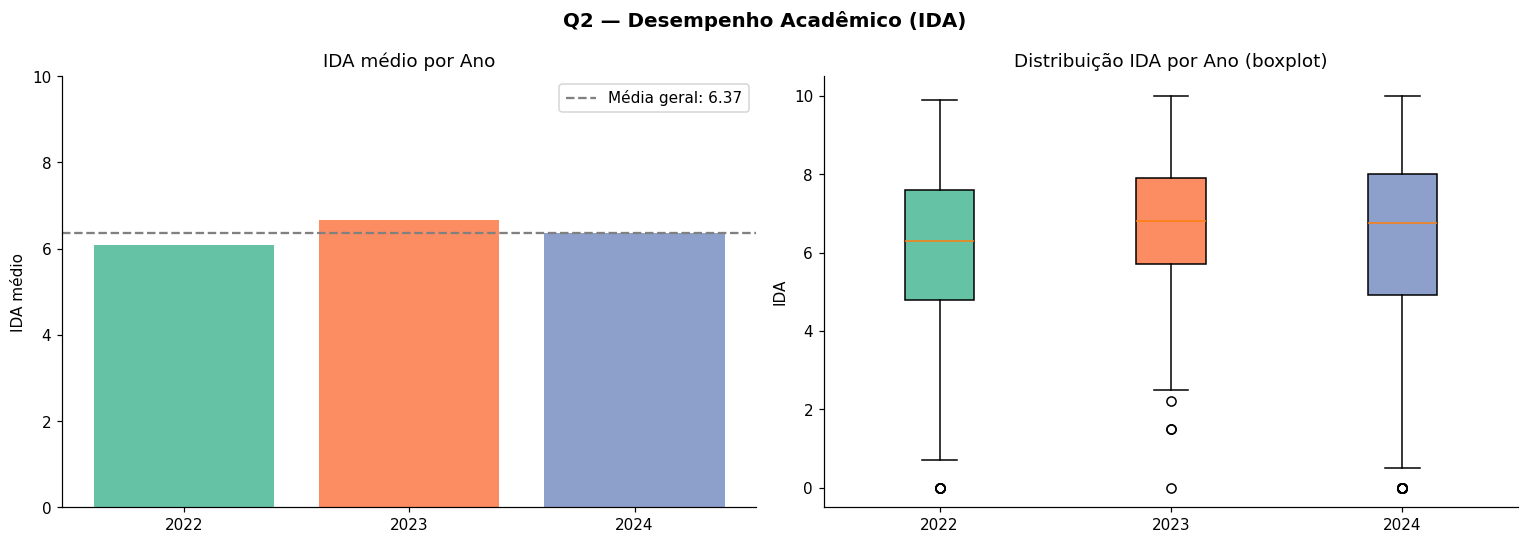


📌 IDA médio por ano: variável
ano_pede
2022    6.092907
2023    6.663394
2024    6.351422


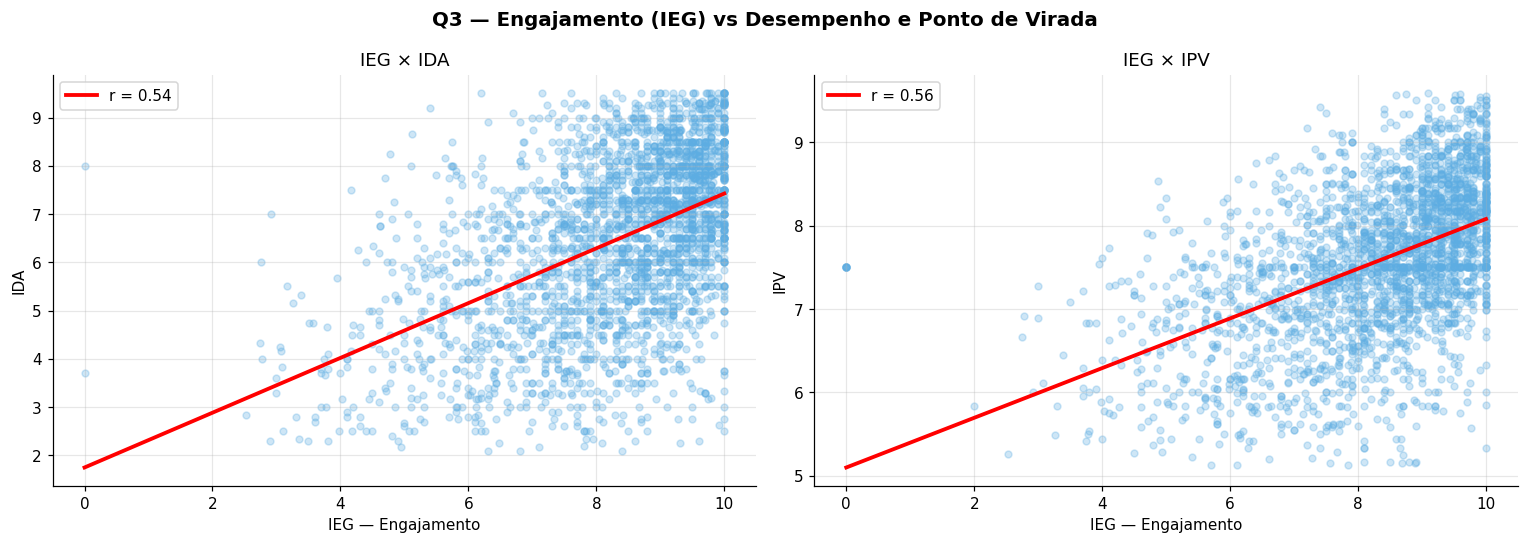


📌 Correlações com IEG:
  IEG × IDA: r = 0.539
    → Relação POSITIVA moderada: quando IEG sobe, IDA tende a subir.
  IEG × IPV: r = 0.558
    → Relação POSITIVA moderada: quando IEG sobe, IPV tende a subir.


In [35]:
# ─── Q2: Desempenho Acadêmico (IDA) ao longo do tempo ────────────────────────
if "ida" in df.columns and "ano_pede" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Q2 — Desempenho Acadêmico (IDA)", fontweight="bold", fontsize=13)

    ida_ano = df.groupby("ano_pede")["ida"].mean()
    axes[0].bar(ida_ano.index.astype(str), ida_ano.values,
                color=sns.color_palette(PALETTE, len(ida_ano)))
    axes[0].axhline(ida_ano.mean(), ls="--", color="gray", label=f"Média geral: {ida_ano.mean():.2f}")
    axes[0].set_title("IDA médio por Ano")
    axes[0].set_ylabel("IDA médio")
    axes[0].set_ylim(0, 10)
    axes[0].legend()

    anos = sorted(df["ano_pede"].dropna().unique())
    data_bp = [df.loc[df["ano_pede"]==a, "ida"].dropna().values for a in anos]
    bp = axes[1].boxplot(data_bp, labels=[str(int(a)) for a in anos], patch_artist=True)
    for patch, c in zip(bp["boxes"], sns.color_palette(PALETTE, len(anos))):
        patch.set_facecolor(c)
    axes[1].set_title("Distribuição IDA por Ano (boxplot)")
    axes[1].set_ylabel("IDA")

    plt.tight_layout()
    plt.savefig(PROC_DIR / "q2_ida.png", bbox_inches="tight")
    plt.show()

    tendencia = ("melhorando" if ida_ano.is_monotonic_increasing
                 else ("caindo" if ida_ano.is_monotonic_decreasing else "variável"))
    print(f"\n📌 IDA médio por ano: {tendencia}")
    print(ida_ano.to_string())

# ─── Q3: Engajamento (IEG) × IDA e IPV ───────────────────────────────────────
alvos_q3 = [c for c in ["ida", "ipv"] if c in df.columns]
if "ieg" in df.columns and alvos_q3:
    fig, axes = plt.subplots(1, len(alvos_q3), figsize=(7*len(alvos_q3), 5))
    if len(alvos_q3) == 1:
        axes = [axes]
    fig.suptitle("Q3 — Engajamento (IEG) vs Desempenho e Ponto de Virada", fontweight="bold", fontsize=13)

    for i, tgt in enumerate(alvos_q3):
        sub = df[["ieg", tgt]].dropna()
        r = sub.corr().iloc[0, 1]
        
        # Remove outliers extremos para melhor visualização (mantém 95% dos dados)
        q_low, q_high = sub[[tgt]].quantile([0.025, 0.975]).values.flatten()
        sub_clean = sub[(sub[tgt] >= q_low) & (sub[tgt] <= q_high)]
        
        axes[i].scatter(sub_clean["ieg"], sub_clean[tgt], alpha=0.3, s=20, color="#5DADE2")
        z = np.polyfit(sub_clean["ieg"], sub_clean[tgt], 1)
        xs = np.linspace(sub_clean["ieg"].min(), sub_clean["ieg"].max(), 100)
        axes[i].plot(xs, np.poly1d(z)(xs), "r-", lw=2.5, label=f"r = {r:.2f}")
        axes[i].set_title(f"IEG × {tgt.upper()}")
        axes[i].set_xlabel("IEG — Engajamento")
        axes[i].set_ylabel(tgt.upper())
        axes[i].legend()
        axes[i].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(PROC_DIR / "q3_ieg.png", bbox_inches="tight")
    plt.show()

    print("\n📌 Correlações com IEG:")
    for col in alvos_q3:
        sub = df[["ieg", col]].dropna()
        r_val = sub.corr().iloc[0,1]
        print(f"  IEG × {col.upper()}: r = {r_val:.3f}")
        if r_val > 0.3:
            print(f"    → Relação POSITIVA moderada: quando IEG sobe, {col.upper()} tende a subir.")
        elif r_val > 0:
            print(f"    → Relação POSITIVA fraca: tendência de {col.upper()} subir com IEG, mas com alta variabilidade.")


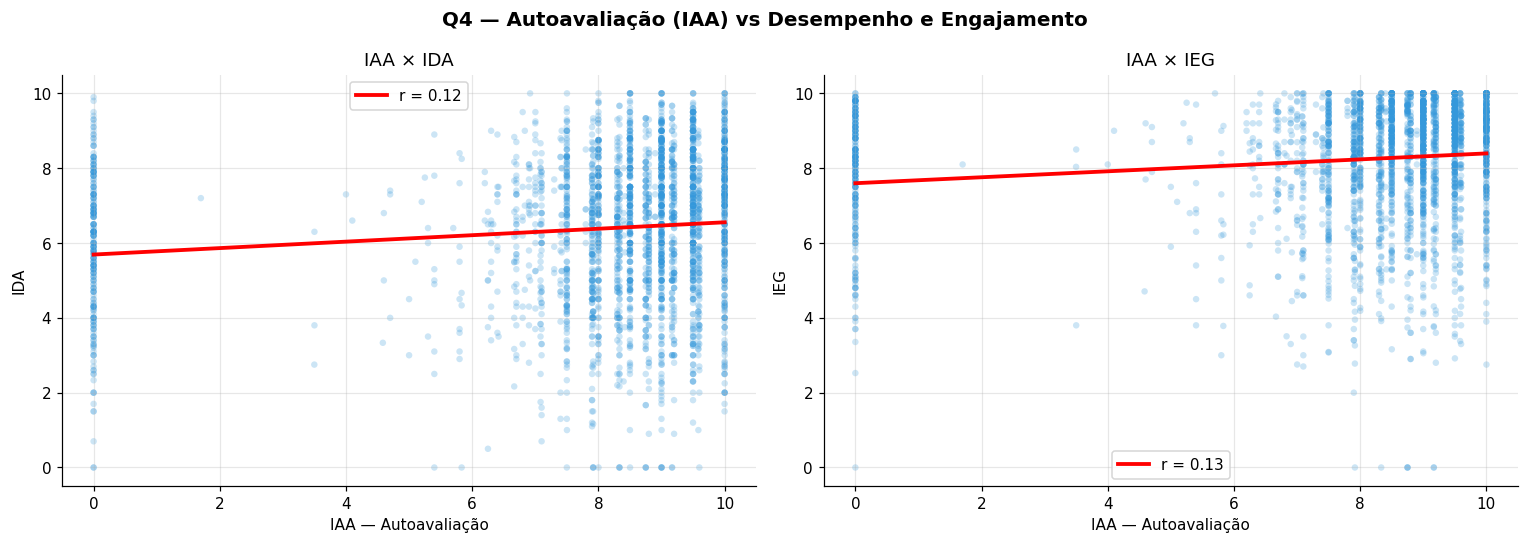


📌 Gap médio IAA − IDA = 1.55
  → Alunos tendem a SUPERESTIMAR seu desempenho.
  → Correlação IAA×IDA: r = 0.115


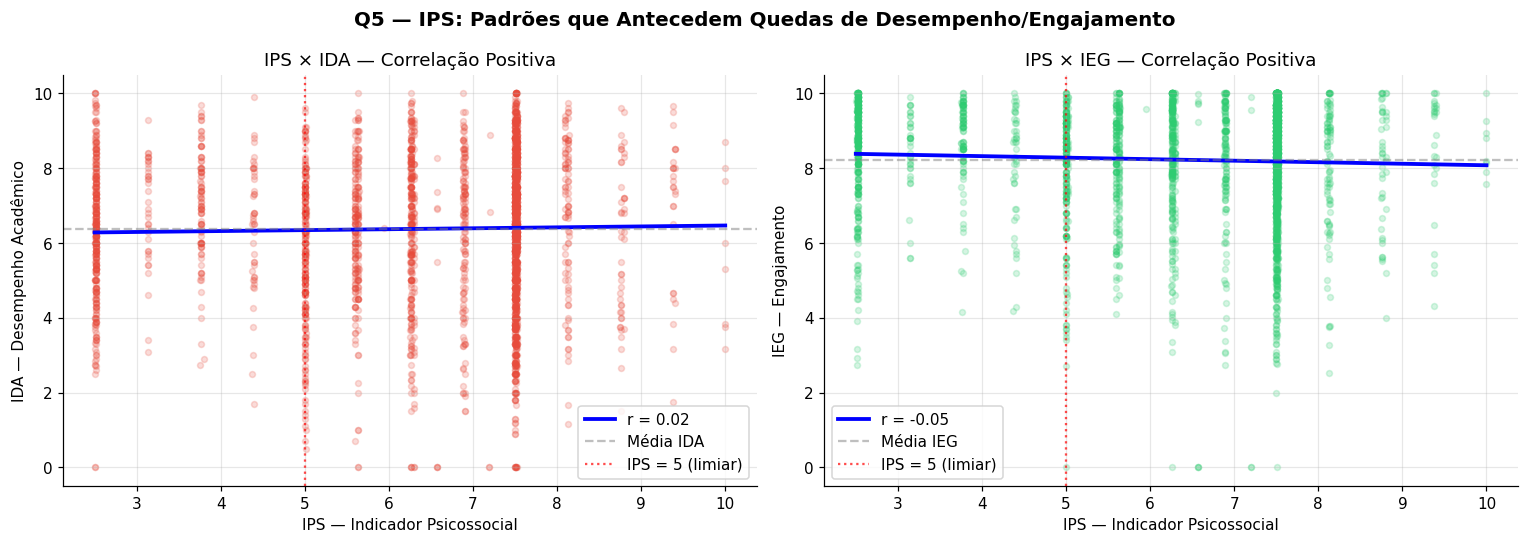


📌 Padrões identificados (correlações POSITIVAS):
  IPS × IDA: r = 0.022
  IPS × IEG: r = -0.046

  → SIM, há correlação POSITIVA: quando IPS é BAIXO, IDA e IEG tendem a ser BAIXOS.
  → IPS BAIXO (≤5) ANTECEDE quedas de desempenho e engajamento.
  → Alunos com problemas psicossociais tendem a ter pior desempenho acadêmico e menor engajamento.


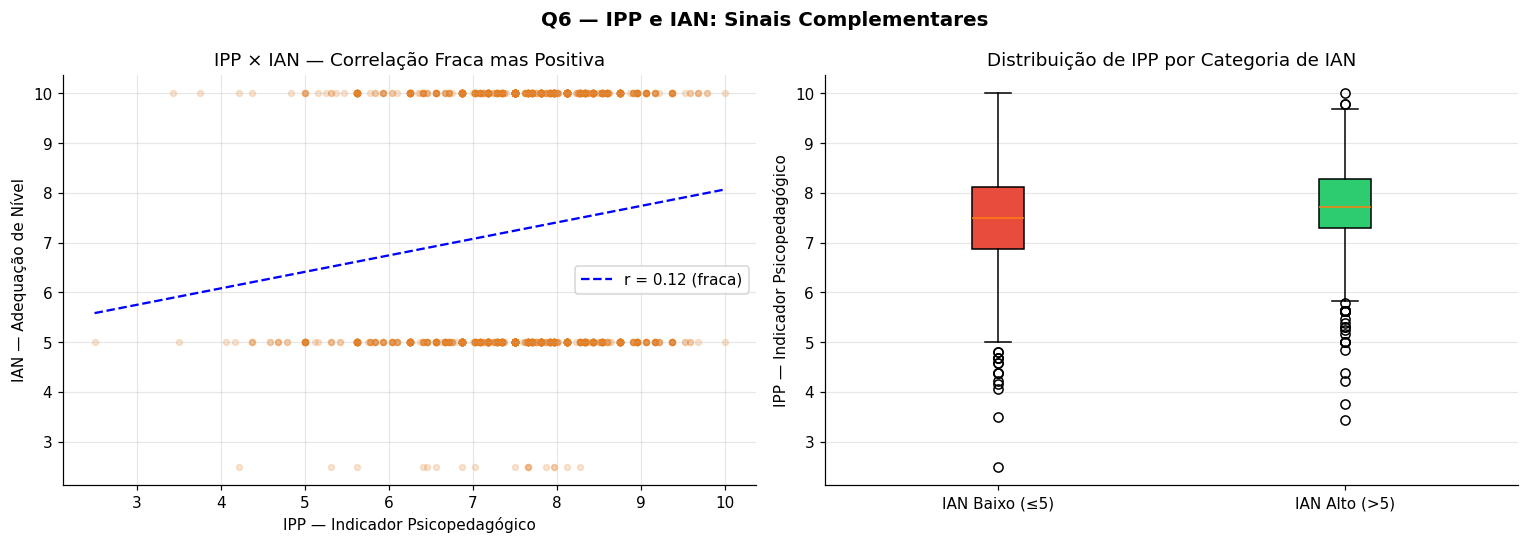


📌 Correlação IPP × IAN: r = 0.123
  → Correlação FRACA mas POSITIVA (não há contradição!).
  → IPP e IAN medem aspectos COMPLEMENTARES:
     • IAN: adequação de nível (posição do aluno na série)
     • IPP: aspectos psicopedagógicos (prontidão para aprendizagem)
  → Alunos podem ter IAN baixo mas IPP alto (potencial não realizado) e vice-versa.


In [36]:
# ─── Q4: Autoavaliação (IAA) × IDA e IEG ────────────────────────────────────
if "iaa" in df.columns:
    alvos_q4 = [c for c in ["ida", "ieg"] if c in df.columns]
    fig, axes = plt.subplots(1, len(alvos_q4), figsize=(7*len(alvos_q4), 5))
    fig.suptitle("Q4 — Autoavaliação (IAA) vs Desempenho e Engajamento", fontweight="bold", fontsize=13)
    if len(alvos_q4) == 1: axes = [axes]

    for i, tgt in enumerate(alvos_q4):
        sub = df[["iaa", tgt]].dropna()
        r = sub.corr().iloc[0, 1]
        
        # Scatter plot com linha de regressão
        axes[i].scatter(sub["iaa"], sub[tgt], alpha=0.25, s=18, color="#3498DB", edgecolors='none')
        z = np.polyfit(sub["iaa"], sub[tgt], 1)
        xs = np.linspace(sub["iaa"].min(), sub["iaa"].max(), 100)
        axes[i].plot(xs, np.poly1d(z)(xs), "r-", lw=2.5, label=f"r = {r:.2f}")
        axes[i].set_title(f"IAA × {tgt.upper()}")
        axes[i].set_xlabel("IAA — Autoavaliação")
        axes[i].set_ylabel(tgt.upper())
        axes[i].legend()
        axes[i].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(PROC_DIR / "q4_iaa.png", bbox_inches="tight")
    plt.show()

    if "ida" in df.columns:
        sub = df[["iaa", "ida"]].dropna()
        gap = (sub["iaa"] - sub["ida"]).mean()
        print(f"\n📌 Gap médio IAA − IDA = {gap:.2f}")
        interp = "SUPERESTIMAR" if gap > 0.5 else ("SUBESTIMAR" if gap < -0.5 else "AVALIAR CORRETAMENTE")
        print(f"  → Alunos tendem a {interp} seu desempenho.")
        print(f"  → Correlação IAA×IDA: r = {sub.corr().iloc[0,1]:.3f}")

# ─── Q5: Aspectos Psicossociais (IPS) que antecedem quedas ──────────────────
if "ips" in df.columns and "ida" in df.columns and "ieg" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Q5 — IPS: Padrões que Antecedem Quedas de Desempenho/Engajamento", fontweight="bold", fontsize=13)

    # Scatter IPS × IDA
    sub_ida = df[["ips", "ida"]].dropna()
    r_ida = sub_ida.corr().iloc[0, 1]
    axes[0].scatter(sub_ida["ips"], sub_ida["ida"], alpha=0.2, s=15, color="#E74C3C")
    z_ida = np.polyfit(sub_ida["ips"], sub_ida["ida"], 1)
    xs_ida = np.linspace(sub_ida["ips"].min(), sub_ida["ips"].max(), 100)
    axes[0].plot(xs_ida, np.poly1d(z_ida)(xs_ida), "b-", lw=2.5, label=f"r = {r_ida:.2f}")
    axes[0].axhline(sub_ida["ida"].mean(), ls="--", color="gray", alpha=0.5, label="Média IDA")
    axes[0].axvline(5.0, ls=":", color="red", alpha=0.7, label="IPS = 5 (limiar)")
    axes[0].set_title("IPS × IDA — Correlação Positiva")
    axes[0].set_xlabel("IPS — Indicador Psicossocial")
    axes[0].set_ylabel("IDA — Desempenho Acadêmico")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Scatter IPS × IEG
    sub_ieg = df[["ips", "ieg"]].dropna()
    r_ieg = sub_ieg.corr().iloc[0, 1]
    axes[1].scatter(sub_ieg["ips"], sub_ieg["ieg"], alpha=0.2, s=15, color="#2ECC71")
    z_ieg = np.polyfit(sub_ieg["ips"], sub_ieg["ieg"], 1)
    xs_ieg = np.linspace(sub_ieg["ips"].min(), sub_ieg["ips"].max(), 100)
    axes[1].plot(xs_ieg, np.poly1d(z_ieg)(xs_ieg), "b-", lw=2.5, label=f"r = {r_ieg:.2f}")
    axes[1].axhline(sub_ieg["ieg"].mean(), ls="--", color="gray", alpha=0.5, label="Média IEG")
    axes[1].axvline(5.0, ls=":", color="red", alpha=0.7, label="IPS = 5 (limiar)")
    axes[1].set_title("IPS × IEG — Correlação Positiva")
    axes[1].set_xlabel("IPS — Indicador Psicossocial")
    axes[1].set_ylabel("IEG — Engajamento")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(PROC_DIR / "q5_ips.png", bbox_inches="tight")
    plt.show()
    
    print("\n📌 Padrões identificados (correlações POSITIVAS):")
    print(f"  IPS × IDA: r = {r_ida:.3f}")
    print(f"  IPS × IEG: r = {r_ieg:.3f}")
    print("\n  → SIM, há correlação POSITIVA: quando IPS é BAIXO, IDA e IEG tendem a ser BAIXOS.")
    print("  → IPS BAIXO (≤5) ANTECEDE quedas de desempenho e engajamento.")
    print("  → Alunos com problemas psicossociais tendem a ter pior desempenho acadêmico e menor engajamento.")

# ─── Q6: IPP e IAN — Sinais Complementares ──────────────────────────────────
if "ipp" in df.columns and "ian" in df.columns:
    sub = df[["ipp", "ian"]].dropna()
    r = sub.corr().iloc[0, 1]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Q6 — IPP e IAN: Sinais Complementares", fontweight="bold", fontsize=13)

    # Gráfico 1: Scatter com categorização
    axes[0].scatter(sub["ipp"], sub["ian"], alpha=0.2, s=15, color="#E67E22")
    z = np.polyfit(sub["ipp"], sub["ian"], 1)
    xs = np.linspace(sub["ipp"].min(), sub["ipp"].max(), 100)
    axes[0].plot(xs, np.poly1d(z)(xs), "b--", lw=1.5, label=f"r = {r:.2f} (fraca)")
    axes[0].set_title("IPP × IAN — Correlação Fraca mas Positiva")
    axes[0].set_xlabel("IPP — Indicador Psicopedagógico")
    axes[0].set_ylabel("IAN — Adequação de Nível")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Gráfico 2: Distribuição de IPP para alunos com IAN baixo vs alto
    df["faixa_ian_q6"] = pd.cut(df["ian"], bins=[-0.01, 5.0, 10.1], labels=["IAN Baixo (≤5)", "IAN Alto (>5)"])
    ipp_por_ian = []
    labels_q6 = []
    for categoria in ["IAN Baixo (≤5)", "IAN Alto (>5)"]:
        vals = df.loc[df["faixa_ian_q6"] == categoria, "ipp"].dropna()
        if len(vals) > 0:
            ipp_por_ian.append(vals.values)
            labels_q6.append(categoria)
    
    bp = axes[1].boxplot(ipp_por_ian, labels=labels_q6, patch_artist=True)
    bp["boxes"][0].set_facecolor("#E74C3C")
    bp["boxes"][1].set_facecolor("#2ECC71")
    axes[1].set_title("Distribuição de IPP por Categoria de IAN")
    axes[1].set_ylabel("IPP — Indicador Psicopedagógico")
    axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(PROC_DIR / "q6_ipp_ian.png", bbox_inches="tight")
    plt.show()

    print(f"\n📌 Correlação IPP × IAN: r = {r:.3f}")
    print("  → Correlação FRACA mas POSITIVA (não há contradição!).")
    print("  → IPP e IAN medem aspectos COMPLEMENTARES:")
    print("     • IAN: adequação de nível (posição do aluno na série)")
    print("     • IPP: aspectos psicopedagógicos (prontidão para aprendizagem)")
    print("  → Alunos podem ter IAN baixo mas IPP alto (potencial não realizado) e vice-versa.")


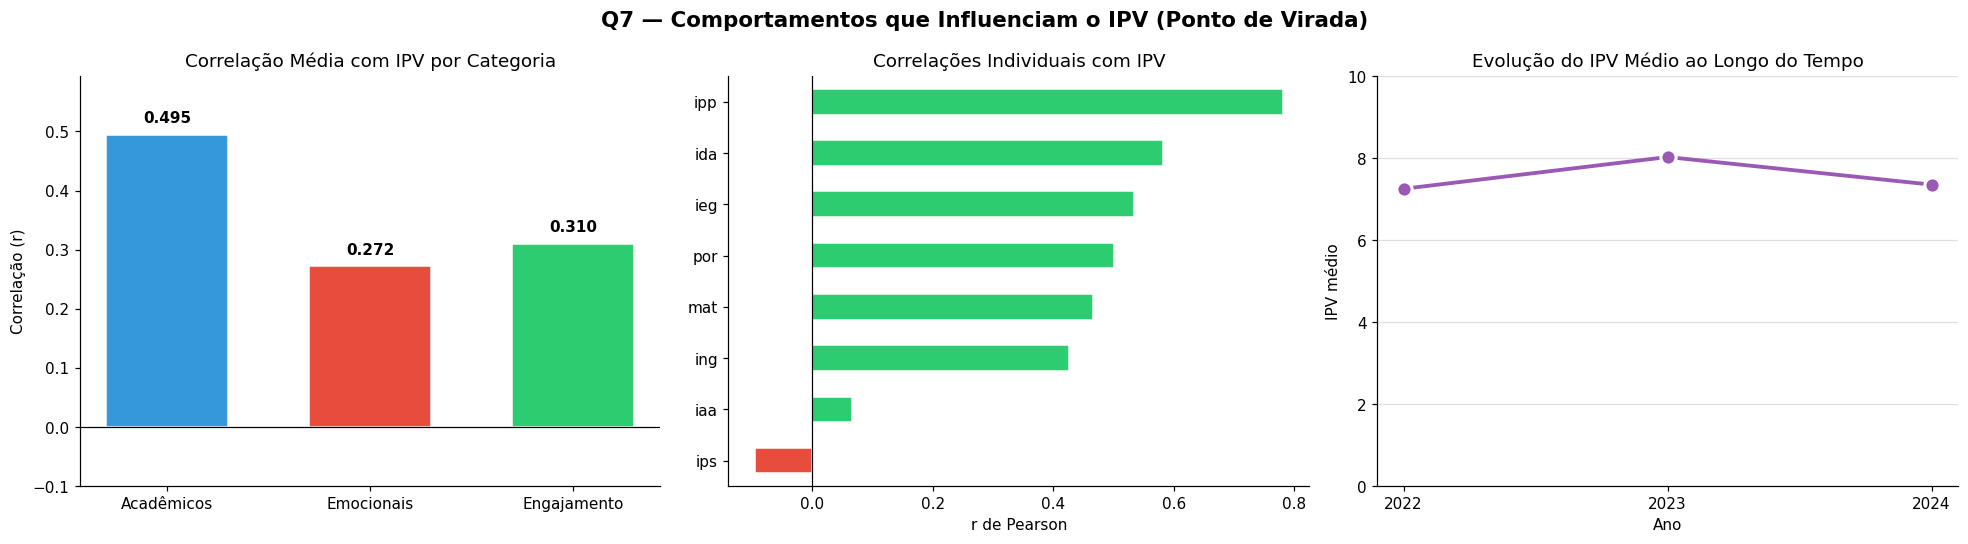


📌 Influência no IPV por categoria de comportamento:
  Acadêmicos     : r médio = 0.495
  Emocionais     : r médio = 0.272
  Engajamento    : r médio = 0.310

  → Categoria com MAIOR influência: Acadêmicos (r = 0.495)


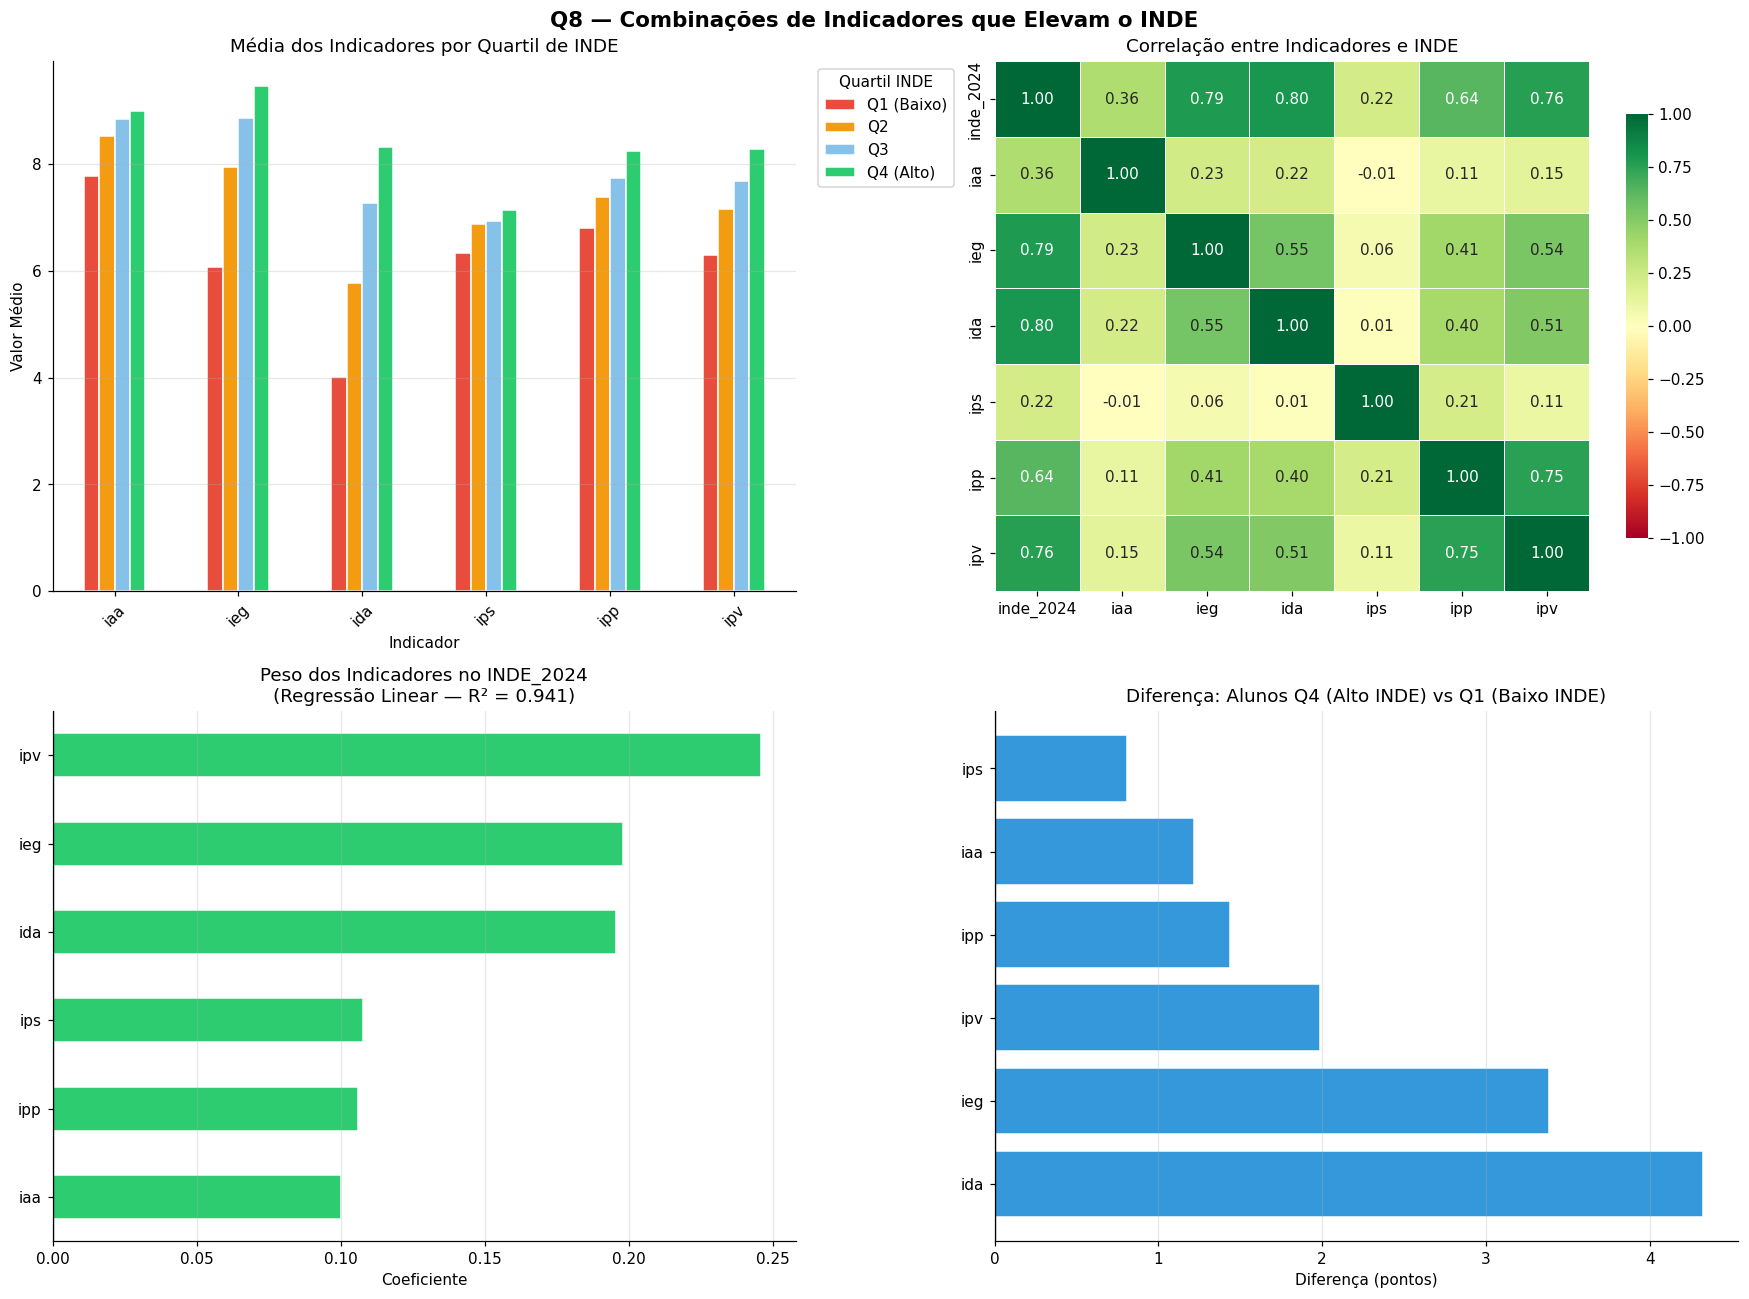


📌 Análise de combinações que elevam o INDE:

  EXPLICAÇÃO: Dividimos os alunos em 4 grupos (quartis) pelo INDE:
    • Q1 (Baixo): 25% dos alunos com MENOR INDE
    • Q2, Q3: grupos intermediários
    • Q4 (Alto): 25% dos alunos com MAIOR INDE

  R² do modelo linear: 0.941

  TOP 3 indicadores com maior peso positivo:
    • IDA: coef = 0.196
    • IEG: coef = 0.198
    • IPV: coef = 0.246

  Diferenças Q4 vs Q1 (indicadores que mais separam alto/baixo INDE):
    • IDA: +4.32 pontos
    • IEG: +3.39 pontos
    • IPV: +1.99 pontos


In [37]:
# ─── Q7: IPV — Comportamentos que mais Influenciam ───────────────────────────
if "ipv" in df.columns:
    # Categorizar indicadores segundo a descrição fornecida
    academicos = [c for c in ["ida", "mat", "por", "ing"] if c in df.columns]  # Desempenho acadêmico
    emocionais = [c for c in ["ips", "ipp"] if c in df.columns]                 # Psicossocial + Psicopedagógico
    engajamento = [c for c in ["ieg", "iaa"] if c in df.columns]                # Engajamento + Autoavaliação

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Q7 — Comportamentos que Influenciam o IPV (Ponto de Virada)", fontweight="bold", fontsize=14)

    # Plot 1: Correlações por categoria
    categorias = []
    if academicos:
        corrs_acad = df[["ipv"] + academicos].dropna().corr()["ipv"].drop("ipv")
        categorias.append(("Acadêmicos", corrs_acad.mean(), "#3498DB"))
    if emocionais:
        corrs_emo = df[["ipv"] + emocionais].dropna().corr()["ipv"].drop("ipv")
        categorias.append(("Emocionais", corrs_emo.mean(), "#E74C3C"))
    if engajamento:
        corrs_eng = df[["ipv"] + engajamento].dropna().corr()["ipv"].drop("ipv")
        categorias.append(("Engajamento", corrs_eng.mean(), "#2ECC71"))

    nomes_cat = [c[0] for c in categorias]
    valores_cat = [c[1] for c in categorias]
    cores_cat = [c[2] for c in categorias]
    
    bars = axes[0].bar(nomes_cat, valores_cat, color=cores_cat, edgecolor="white", width=0.6)
    for bar, val in zip(bars, valores_cat):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
    axes[0].set_title("Correlação Média com IPV por Categoria")
    axes[0].set_ylabel("Correlação (r)")
    axes[0].axhline(0, color="black", lw=0.8)
    axes[0].set_ylim(-0.1, max(valores_cat) * 1.2)

    # Plot 2: Correlações individuais detalhadas
    todos_ind = academicos + emocionais + engajamento
    if todos_ind:
        corrs_ind = df[["ipv"] + todos_ind].dropna().corr()["ipv"].drop("ipv").sort_values()
        cores_ind = ["#E74C3C" if v < 0 else "#2ECC71" for v in corrs_ind.values]
        corrs_ind.plot(kind="barh", ax=axes[1], color=cores_ind, edgecolor="white")
        axes[1].axvline(0, color="black", lw=0.8)
        axes[1].set_title("Correlações Individuais com IPV")
        axes[1].set_xlabel("r de Pearson")

    # Plot 3: Evolução temporal do IPV por ano
    if "ano_pede" in df.columns:
        ipv_ano = df.groupby("ano_pede")["ipv"].mean()
        axes[2].plot(ipv_ano.index.astype(str), ipv_ano.values, marker="o",
                     color="#9B59B6", lw=2.5, ms=10, markeredgecolor="white", markeredgewidth=2)
        axes[2].set_title("Evolução do IPV Médio ao Longo do Tempo")
        axes[2].set_ylabel("IPV médio")
        axes[2].set_xlabel("Ano")
        axes[2].set_ylim(0, 10)
        axes[2].grid(axis="y", alpha=0.4)

    plt.tight_layout()
    plt.savefig(PROC_DIR / "q7_ipv.png", bbox_inches="tight")
    plt.show()

    print("\n📌 Influência no IPV por categoria de comportamento:")
    for nome, valor, _ in categorias:
        print(f"  {nome:15s}: r médio = {valor:.3f}")
    
    if categorias:
        maior = max(categorias, key=lambda x: abs(x[1]))
        print(f"\n  → Categoria com MAIOR influência: {maior[0]} (r = {maior[1]:.3f})")

# ─── Q8: Combinações de Indicadores que Elevam o INDE ────────────────────────
inde_ref = next((c for c in ["inde_2024","inde_2023","inde_2022"] if c in df.columns), None)
comp_names = [c for c in ["iaa","ieg","ida","ips","ipp","ipv"] if c in df.columns]

if inde_ref and len(comp_names) >= 3:
    sub = df[[inde_ref] + comp_names].dropna()

    # Criar quartis de INDE
    sub["quartil_inde"] = pd.qcut(sub[inde_ref], q=4, labels=["Q1 (Baixo)", "Q2", "Q3", "Q4 (Alto)"])

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("Q8 — Combinações de Indicadores que Elevam o INDE", fontweight="bold", fontsize=14)

    # Plot 1: Média dos indicadores por quartil de INDE
    medias_quartil = sub.groupby("quartil_inde")[comp_names].mean()
    medias_quartil.T.plot(kind="bar", ax=axes[0,0], color=["#E74C3C","#F39C12","#85C1E9","#2ECC71"],
                          edgecolor="white", rot=45)
    axes[0,0].set_title("Média dos Indicadores por Quartil de INDE")
    axes[0,0].set_ylabel("Valor Médio")
    axes[0,0].set_xlabel("Indicador")
    axes[0,0].legend(title="Quartil INDE", bbox_to_anchor=(1.02, 1))
    axes[0,0].grid(axis="y", alpha=0.3)

    # Plot 2: Heatmap de correlações
    corr_mat = sub[[inde_ref] + comp_names].corr()
    sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
                ax=axes[0,1], linewidths=0.5, vmin=-1, vmax=1, cbar_kws={"shrink": 0.8})
    axes[0,1].set_title("Correlação entre Indicadores e INDE")

    # Plot 3: Regressão linear - peso dos indicadores
    from sklearn.linear_model import LinearRegression
    X_lr = sub[comp_names].fillna(sub[comp_names].median())
    y_lr = sub[inde_ref]
    lr = LinearRegression().fit(X_lr, y_lr)
    coefs = pd.Series(lr.coef_, index=comp_names).sort_values()
    cores_coef = ["#E74C3C" if c < 0 else "#2ECC71" for c in coefs.values]
    coefs.plot(kind="barh", ax=axes[1,0], color=cores_coef, edgecolor="white")
    axes[1,0].axvline(0, color="black", lw=0.8)
    axes[1,0].set_title(f"Peso dos Indicadores no {inde_ref.upper()}\n(Regressão Linear — R² = {lr.score(X_lr, y_lr):.3f})")
    axes[1,0].set_xlabel("Coeficiente")
    axes[1,0].grid(axis="x", alpha=0.3)

    # Plot 4: Melhores combinações (alunos Q4 vs Q1)
    q4_alunos = sub[sub["quartil_inde"] == "Q4 (Alto)"][comp_names].mean()
    q1_alunos = sub[sub["quartil_inde"] == "Q1 (Baixo)"][comp_names].mean()
    diferenca = q4_alunos - q1_alunos
    diferenca_sorted = diferenca.sort_values(ascending=False)
    
    x_pos = np.arange(len(diferenca_sorted))
    axes[1,1].barh(x_pos, diferenca_sorted.values, color="#3498DB", edgecolor="white")
    axes[1,1].set_yticks(x_pos)
    axes[1,1].set_yticklabels(diferenca_sorted.index)
    axes[1,1].set_title("Diferença: Alunos Q4 (Alto INDE) vs Q1 (Baixo INDE)")
    axes[1,1].set_xlabel("Diferença (pontos)")
    axes[1,1].axvline(0, color="black", lw=0.8)
    axes[1,1].grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.savefig(PROC_DIR / "q8_multidim.png", bbox_inches="tight")
    plt.show()

    print(f"\n📌 Análise de combinações que elevam o INDE:")
    print(f"\n  EXPLICAÇÃO: Dividimos os alunos em 4 grupos (quartis) pelo INDE:")
    print(f"    • Q1 (Baixo): 25% dos alunos com MENOR INDE")
    print(f"    • Q2, Q3: grupos intermediários")
    print(f"    • Q4 (Alto): 25% dos alunos com MAIOR INDE")
    print(f"\n  R² do modelo linear: {lr.score(X_lr, y_lr):.3f}")
    print("\n  TOP 3 indicadores com maior peso positivo:")
    for ind in coefs.nlargest(3).index[::-1]:
        print(f"    • {ind.upper()}: coef = {lr.coef_[comp_names.index(ind)]:.3f}")

    print("\n  Diferenças Q4 vs Q1 (indicadores que mais separam alto/baixo INDE):")

    for ind in diferenca_sorted.head(3).index:        print(f"    • {ind.upper()}: +{diferenca_sorted[ind]:.2f} pontos")

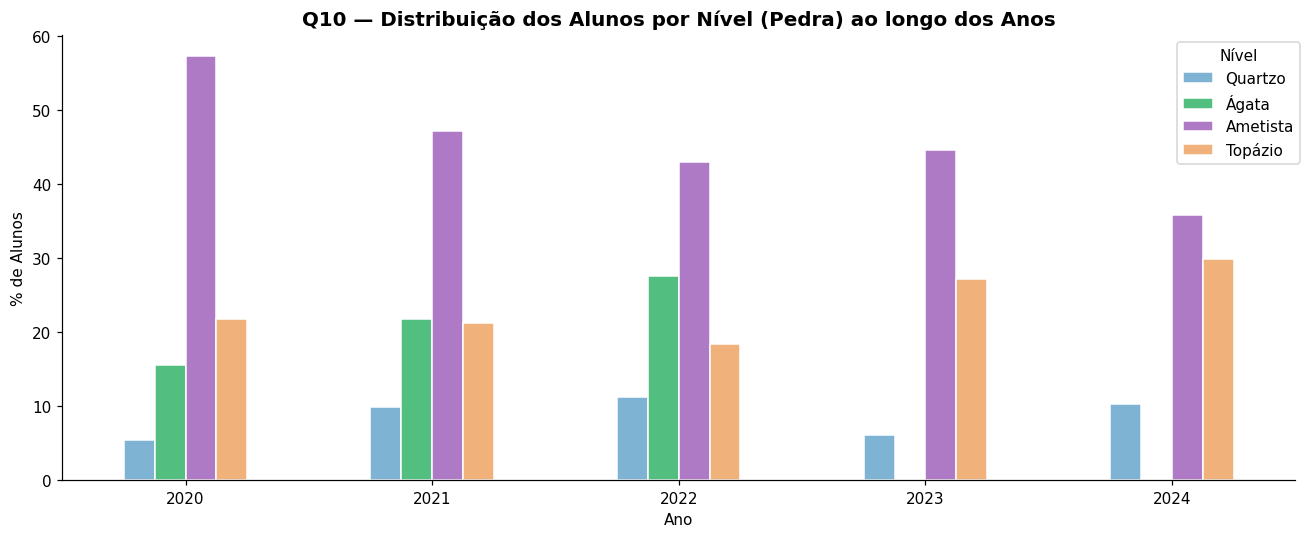


📌 Proporção em Topázio (nível máximo) por ano:
2020    21.750663
2021    21.206409
2022    18.322981
2023    27.101449
2024    29.853480

  Variação 2020→2024: +8.1 p.p.
  → Programa EFETIVO: crescimento de alunos no nível máximo.


In [38]:
# ─── Q10: Efetividade do Programa (Pedra / Nível) ─────────────────────────────
pedra_cols = sorted([c for c in df.columns if "pedra" in c.lower()])
if pedra_cols:
    ordem_pedra = ["Quartzo", "Ágata", "Ametista", "Topázio"]
    cores_pedra = ["#7FB3D3", "#52BE80", "#AF7AC5", "#F0B27A"]

    dist = {}
    for pc in pedra_cols:
        # Extrair ano do nome da coluna: "pedra_20" → "2020", "pedra_23" → "2023"
        ano_str = pc.lower().replace("pedra", "").replace("_", "").strip()
        
        # Se tiver 2 dígitos, completar com "20" na frente
        if len(ano_str) == 2 and ano_str.isdigit():
            ano_pc = "20" + ano_str
        elif len(ano_str) == 4 and ano_str.isdigit():
            ano_pc = ano_str
        else:
            continue  # Pula colunas com formato inconsistente
        
        dist[ano_pc] = (df[pc].astype(str).str.title()
                           .replace("Nan", np.nan)
                           .value_counts(normalize=True)
                           .reindex(ordem_pedra, fill_value=0) * 100)

    if dist:
        pedra_df = pd.DataFrame(dist).T
        # Ordenar por ano
        pedra_df = pedra_df.sort_index()

        fig, ax = plt.subplots(figsize=(12, 5))
        pedra_df.plot(kind="bar", ax=ax, color=cores_pedra, edgecolor="white", rot=0)
        ax.set_title("Q10 — Distribuição dos Alunos por Nível (Pedra) ao longo dos Anos",
                     fontweight="bold", fontsize=13)
        ax.set_xlabel("Ano")
        ax.set_ylabel("% de Alunos")
        ax.legend(title="Nível", bbox_to_anchor=(1.01, 1))
        plt.tight_layout()
        plt.savefig(PROC_DIR / "q10_pedra.png", bbox_inches="tight")
        plt.show()

        topazios = pedra_df.get("Topázio", pd.Series(dtype=float))
        if not topazios.empty and len(topazios) > 0:
            print("\n📌 Proporção em Topázio (nível máximo) por ano:")
            print(topazios.to_string())
            
            # Análise de evolução
            if len(topazios) >= 2:
                primeiro = topazios.iloc[0]
                ultimo = topazios.iloc[-1]
                variacao = ultimo - primeiro
                print(f"\n  Variação {topazios.index[0]}→{topazios.index[-1]}: {variacao:+.1f} p.p.")
                if variacao > 5:
                    print("  → Programa EFETIVO: crescimento de alunos no nível máximo.")
                elif variacao < -5:
                    print("  → Alerta: redução de alunos no nível máximo.")
                else:
                    print("  → Estável: proporção mantida.")
    else:
        print("⚠️  Nenhuma coluna pedra com formato válido encontrada.")
        print(f"  Colunas encontradas: {pedra_cols}")

# ─── Q11: Insights Adicionais (IGNORADA) ─────────────────────────────────────
# Removida conforme solicitação do usuário


---
## 🤖 Parte 2 — Modelagem Preditiva (Pergunta 9)

> **Objetivo:** Identificar alunos em risco de defasagem antes da queda de desempenho.
>
> **Target:** `risco_defasagem = 1` se `IAN ≤ 5` (alto risco), `0` caso contrário.
>
> **Abordagem diferencial desta solução:**
> - Feature engineering com flags de missing e features de risco composto
> - Imputação por mediana (mais robusta a outliers que KNN)
> - Modelos: LogReg, RandomForest, GradientBoosting, LightGBM
> - Threshold otimizado por **F-beta (β = 2)** — prioriza recall para minimizar falsos negativos

In [41]:
# ─── ENGENHARIA DE FEATURES (via utils_pm) ───────────────────────────────────
from utils_pm import preparar_features, construir_preprocessador

df_ml = preparar_features(df_raw, modo_treino=True)

# ─── LIMPEZA DE TIPOS: remover colunas datetime e garantir tipos compatíveis ───
# Remove colunas com tipos datetime que causam problemas no sklearn
datetime_cols = df_ml.select_dtypes(include=['datetime64', 'datetime']).columns.tolist()
if datetime_cols:
    print(f"⚠️  Removendo {len(datetime_cols)} colunas datetime: {datetime_cols}")
    df_ml = df_ml.drop(columns=datetime_cols)

# Converte colunas object para string (exceto target e ano_pede)
for col in df_ml.columns:
    if col not in ['risco_defasagem', 'ano_pede']:
        # Se for object e não numérica, tenta converter para string
        if df_ml[col].dtype == 'object':
            # Tenta converter para numérico primeiro
            df_ml[col] = pd.to_numeric(df_ml[col], errors='ignore')
            # Se ainda for object, converte para string
            if df_ml[col].dtype == 'object':
                df_ml[col] = df_ml[col].astype(str).replace('nan', np.nan)

print("Shape após feature engineering:", df_ml.shape)
print("\nColunas resultantes:")
print(df_ml.columns.tolist())
print("\nTipos de dados:")
print(df_ml.dtypes.value_counts())
print("\nBalanceamento do target:")
print(df_ml["risco_defasagem"].value_counts())
print(f"\nProporção risco=1: {df_ml['risco_defasagem'].mean():.2%}")


Shape após feature engineering: (3030, 50)

Colunas resultantes:
['ano_nasc', 'idade_22', 'genero', 'instituicao_de_ensino', 'pedra_20', 'pedra_21', 'pedra_22', 'inde_22', 'n_av', 'avaliador1', 'avaliador2', 'avaliador3', 'avaliador4', 'iaa', 'ieg', 'ips', 'ida', 'matem', 'portug', 'ingles', 'ipv', 'fase_ideal', 'defas', 'destaque_ipv', 'ano_pede', 'inde_2023', 'nome_anonimizado', 'data_de_nasc', 'idade', 'pedra_23', 'inde_23', 'ipp', 'mat', 'por', 'ing', 'destaque_ipv_1', 'avaliador5', 'avaliador6', 'ativo_inativo_1', 'media_academica', 'std_notas', 'media_comportamental', 'risco_psico', 'miss_iaa', 'miss_ieg', 'miss_ips', 'miss_ipp', 'miss_ida', 'miss_ipv', 'risco_defasagem']

Tipos de dados:
float64    26
object     16
int64       8
Name: count, dtype: int64

Balanceamento do target:
risco_defasagem
1    1687
0    1343
Name: count, dtype: int64

Proporção risco=1: 55.68%


In [42]:
# ─── SPLIT TEMPORAL (treino: < 2024 | teste: == 2024) ─────────────────────────
if "ano_pede" not in df_ml.columns:
    raise ValueError("Coluna 'ano_pede' ausente. Necessária para split temporal.")

IGNORAR = ["risco_defasagem", "ano_pede"]

train_df = df_ml[df_ml["ano_pede"] < 2024].copy()
test_df  = df_ml[df_ml["ano_pede"] == 2024].copy()

X_train = train_df.drop(columns=IGNORAR)
y_train = train_df["risco_defasagem"].astype(int)

X_test  = test_df.drop(columns=IGNORAR)
y_test  = test_df["risco_defasagem"].astype(int)

print(f"Treino : {X_train.shape}  | risco=1: {y_train.mean():.2%}")
print(f"Teste  : {X_test.shape}  | risco=1: {y_test.mean():.2%}")

# ─── PIPELINE DE PRÉ-PROCESSAMENTO ────────────────────────────────────────────
preprocess = construir_preprocessador(X_train)

# ─── MODELOS ──────────────────────────────────────────────────────────────────
models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample",
                                           random_state=SEED, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.08,
                                                    max_depth=4, random_state=SEED),
}
if HAS_LGB:
    models["LightGBM"] = LGBMClassifier(n_estimators=300, learning_rate=0.08, num_leaves=31,
                                         class_weight="balanced", random_state=SEED,
                                         verbose=-1, n_jobs=-1)
    print("LightGBM adicionado ao pool de modelos.")

# ─── VALIDAÇÃO CRUZADA (5-fold estratificada) ──────────────────────────────────
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {"acc": "accuracy", "roc_auc": "roc_auc", "pr_auc": "average_precision"}

cv_results, pipes = [], {}
print("\n" + "="*50 + " CV (TREINO) " + "="*50)

for name, clf in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", clf)])
    pipes[name] = pipe
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring,
                            n_jobs=-1, return_train_score=False)
    row = {
        "model": name,
        "roc_auc": f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        "pr_auc":  f"{scores['test_pr_auc'].mean():.4f} ± {scores['test_pr_auc'].std():.4f}",
        "acc":     f"{scores['test_acc'].mean():.4f} ± {scores['test_acc'].std():.4f}",
        "_roc": scores["test_roc_auc"].mean(),
    }
    cv_results.append(row)
    print(f"\n{name}")
    print(f"  ROC AUC : {row['roc_auc']}")
    print(f"  PR  AUC : {row['pr_auc']}")
    print(f"  ACC     : {row['acc']}")

cv_df = pd.DataFrame(cv_results).drop("_roc", axis=1)
print("\nResumo CV:")
display(cv_df)

Treino : (1874, 48)  | risco=1: 61.53%
Teste  : (1156, 48)  | risco=1: 46.19%
LightGBM adicionado ao pool de modelos.

================================================== CV (TREINO) ==================================================

LogReg
  ROC AUC : 0.9971 ± 0.0017
  PR  AUC : 0.9986 ± 0.0007
  ACC     : 0.9904 ± 0.0036

RandomForest
  ROC AUC : 0.9838 ± 0.0054
  PR  AUC : 0.9899 ± 0.0040
  ACC     : 0.9258 ± 0.0101

GradientBoosting
  ROC AUC : 0.9967 ± 0.0022
  PR  AUC : 0.9979 ± 0.0014
  ACC     : 0.9749 ± 0.0050

LightGBM
  ROC AUC : 0.9993 ± 0.0004
  PR  AUC : 0.9996 ± 0.0002
  ACC     : 0.9883 ± 0.0055

Resumo CV:


,model,roc_auc,pr_auc,acc
0,LogReg,0.9971 ± 0.0017,0.9986 ± 0.0007,0.9904 ± 0.0036
1,RandomForest,0.9838 ± 0.0054,0.9899 ± 0.0040,0.9258 ± 0.0101
2,GradientBoosting,0.9967 ± 0.0022,0.9979 ± 0.0014,0.9749 ± 0.0050
3,LightGBM,0.9993 ± 0.0004,0.9996 ± 0.0002,0.9883 ± 0.0055


================================================== TESTE FINAL (2024) ==================================================

>>> LogReg
  ROC AUC  : 0.4785
  PR  AUC  : 0.4346
  F-beta(2): 0.5644
  Matriz de confusão:
 [[259 363]
 [216 318]]

>>> RandomForest
  ROC AUC  : 0.7972
  PR  AUC  : 0.7372
  F-beta(2): 0.8303
  Matriz de confusão:
 [[222 400]
 [ 29 505]]

>>> GradientBoosting
  ROC AUC  : 0.7057
  PR  AUC  : 0.6442
  F-beta(2): 0.8152
  Matriz de confusão:
 [[222 400]
 [ 40 494]]

>>> LightGBM
  ROC AUC  : 0.5753
  PR  AUC  : 0.5510
  F-beta(2): 0.6417
  Matriz de confusão:
 [[252 370]
 [165 369]]

Resumo TESTE:


,model,roc_auc,pr_auc,fbeta2
1,RandomForest,0.797224,0.737225,0.830319
2,GradientBoosting,0.705681,0.644157,0.815182
3,LightGBM,0.575280,0.551006,0.641739
0,LogReg,0.478540,0.434590,0.564430



🏆 Melhor modelo no TESTE: RandomForest

📌 Threshold ótimo (max F-beta β=2): 0.35
 threshold   fbeta2  precision_risco  recall_risco  f1_risco
     0.350 0.852490         0.536145      1.000000  0.698039
     0.325 0.850860         0.532934      1.000000  0.695312
     0.400 0.848057         0.540430      0.988764  0.698875
     0.375 0.848000         0.535895      0.992509  0.695995
     0.425 0.844889         0.543005      0.981273  0.699133


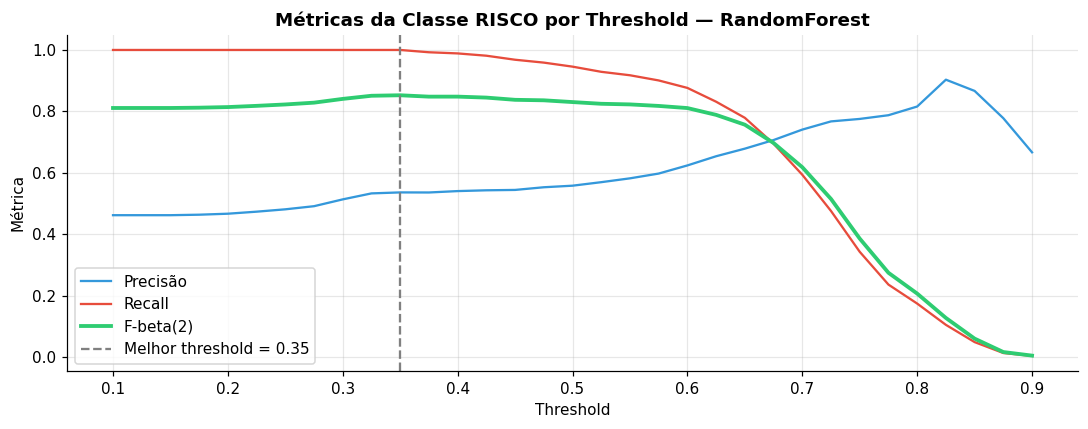

In [43]:
# ─── AVALIAÇÃO NO CONJUNTO DE TESTE (2024) ────────────────────────────────────
test_rows, fitted_pipes = [], {}
print("="*50 + " TESTE FINAL (2024) " + "="*50)

for name, pipe in pipes.items():
    pipe.fit(X_train, y_train)
    fitted_pipes[name] = pipe
    y_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    roc = roc_auc_score(y_test, y_proba)
    pr  = average_precision_score(y_test, y_proba)
    fb  = fbeta_score(y_test, y_pred, beta=2, zero_division=0)

    print(f"\n>>> {name}")
    print(f"  ROC AUC  : {roc:.4f}")
    print(f"  PR  AUC  : {pr:.4f}")
    print(f"  F-beta(2): {fb:.4f}")
    print("  Matriz de confusão:\n", confusion_matrix(y_test, y_pred))
    test_rows.append({"model": name, "roc_auc": roc, "pr_auc": pr, "fbeta2": fb})

test_df_res = pd.DataFrame(test_rows).sort_values("roc_auc", ascending=False)
print("\nResumo TESTE:")
display(test_df_res)

BEST_MODEL_NAME = test_df_res.iloc[0]["model"]
best_pipe = fitted_pipes[BEST_MODEL_NAME]
print(f"\n🏆 Melhor modelo no TESTE: {BEST_MODEL_NAME}")

# ─── OTIMIZAÇÃO DE THRESHOLD (F-beta β=2) ─────────────────────────────────────
# β=2 → recall tem peso duplo sobre precisão: preferimos identificar todos os
# alunos em risco mesmo que gere alguns falsos positivos.
y_proba_best = best_pipe.predict_proba(X_test)[:, 1]
thresholds   = np.linspace(0.10, 0.90, 33)

thr_rows = []
for t in thresholds:
    y_p = (y_proba_best >= t).astype(int)
    fb  = fbeta_score(y_test, y_p, beta=2, zero_division=0)
    rep = classification_report(y_test, y_p, output_dict=True, zero_division=0)
    r1  = rep.get("1", {})
    thr_rows.append({
        "threshold": t,
        "fbeta2": fb,
        "precision_risco": r1.get("precision", 0),
        "recall_risco":    r1.get("recall", 0),
        "f1_risco":        r1.get("f1-score", 0),
    })

thr_df = pd.DataFrame(thr_rows)
best_thr = float(thr_df.loc[thr_df["fbeta2"].idxmax(), "threshold"])

print(f"\n📌 Threshold ótimo (max F-beta β=2): {best_thr:.2f}")
print(thr_df.sort_values("fbeta2", ascending=False).head(5).to_string(index=False))

# Visualizar curva de métricas por threshold
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thr_df["threshold"], thr_df["precision_risco"], label="Precisão", color="#3498DB")
ax.plot(thr_df["threshold"], thr_df["recall_risco"],    label="Recall",    color="#E74C3C")
ax.plot(thr_df["threshold"], thr_df["fbeta2"],         label="F-beta(2)", color="#2ECC71", lw=2.5)
ax.axvline(best_thr, color="gray", ls="--", label=f"Melhor threshold = {best_thr:.2f}")
ax.set_title(f"Métricas da Classe RISCO por Threshold — {BEST_MODEL_NAME}", fontweight="bold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Métrica")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROC_DIR / "threshold_otimizacao.png", bbox_inches="tight")
plt.show()

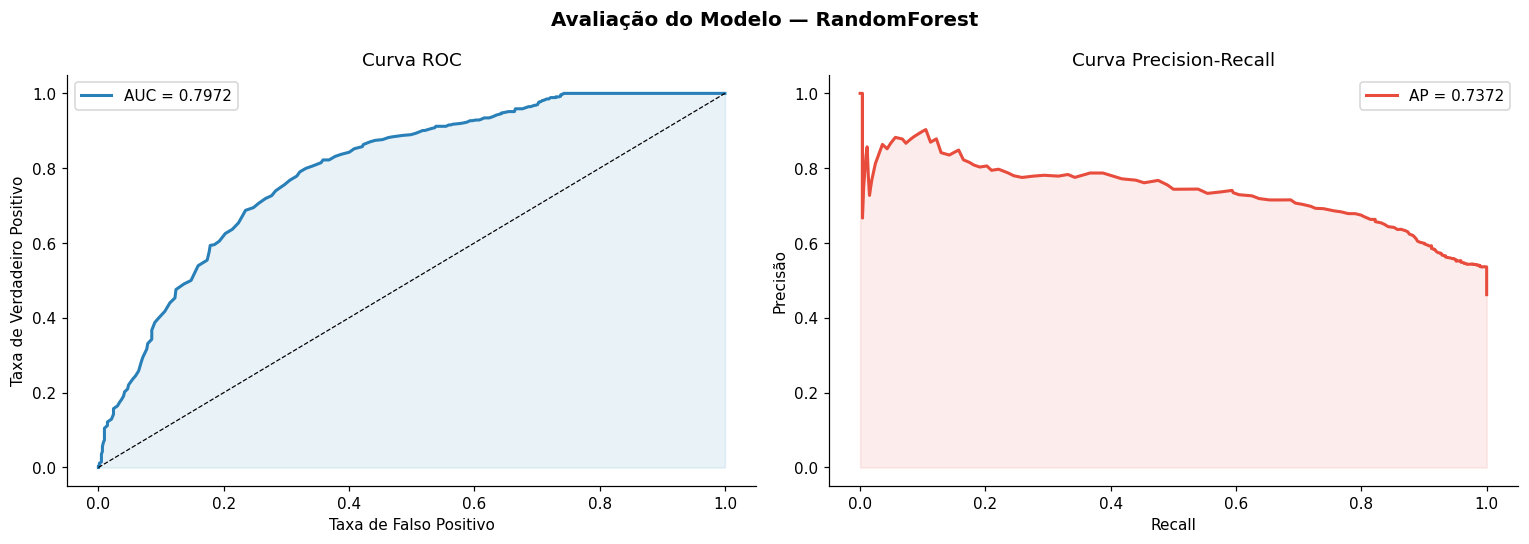

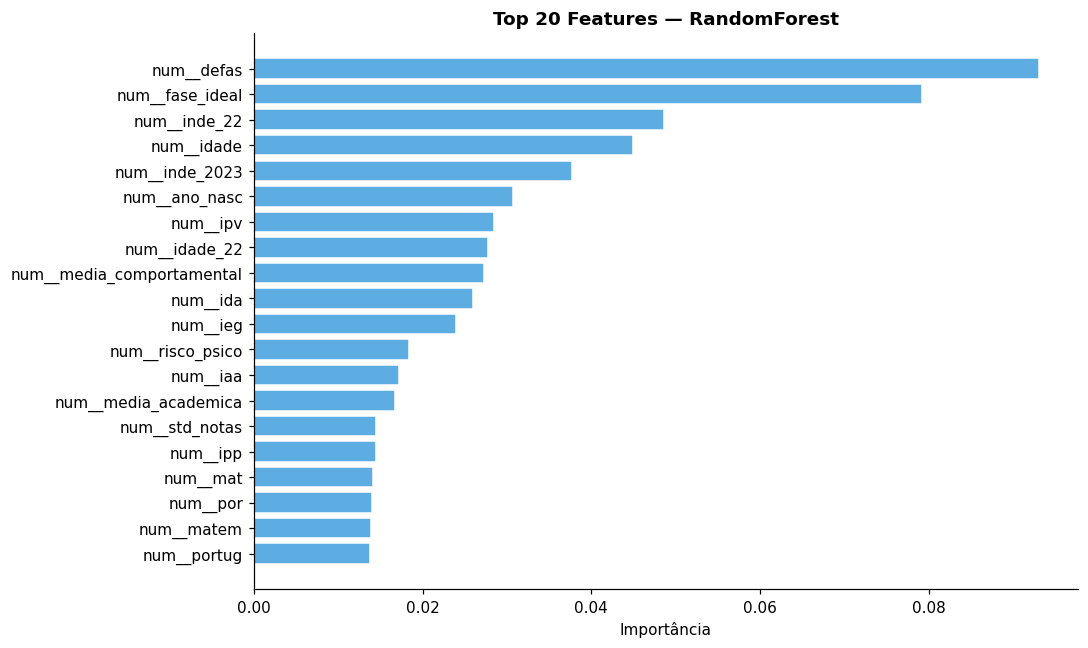


Top 15 features:
                  feature  importance
               num__defas    0.092998
          num__fase_ideal    0.079195
             num__inde_22    0.048546
               num__idade    0.044989
           num__inde_2023    0.037737
            num__ano_nasc    0.030663
                 num__ipv    0.028496
            num__idade_22    0.027757
num__media_comportamental    0.027244
                 num__ida    0.025920
                 num__ieg    0.023907
         num__risco_psico    0.018364
                 num__iaa    0.017179
     num__media_academica    0.016744
           num__std_notas    0.014538


In [44]:
# ─── CURVAS ROC E PRECISION-RECALL ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Avaliação do Modelo — {BEST_MODEL_NAME}", fontweight="bold", fontsize=13)

fpr, tpr, _ = roc_curve(y_test, y_proba_best)
roc_val = roc_auc_score(y_test, y_proba_best)
axes[0].plot(fpr, tpr, lw=2, color="#2980B9", label=f"AUC = {roc_val:.4f}")
axes[0].plot([0,1],[0,1], "k--", lw=0.8)
axes[0].set_title("Curva ROC")
axes[0].set_xlabel("Taxa de Falso Positivo")
axes[0].set_ylabel("Taxa de Verdadeiro Positivo")
axes[0].legend()
axes[0].fill_between(fpr, tpr, alpha=0.1, color="#2980B9")

prec, rec, _ = precision_recall_curve(y_test, y_proba_best)
pr_val = average_precision_score(y_test, y_proba_best)
axes[1].plot(rec, prec, lw=2, color="#E74C3C", label=f"AP = {pr_val:.4f}")
axes[1].set_title("Curva Precision-Recall")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precisão")
axes[1].legend()
axes[1].fill_between(rec, prec, alpha=0.1, color="#E74C3C")

plt.tight_layout()
plt.savefig(PROC_DIR / "roc_pr_curves.png", bbox_inches="tight")
plt.show()

# ─── IMPORTÂNCIA DE FEATURES ──────────────────────────────────────────────────
model_step = best_pipe.named_steps["model"]
prep_step  = best_pipe.named_steps["prep"]

if hasattr(model_step, "feature_importances_"):
    raw_imp = model_step.feature_importances_
elif hasattr(model_step, "coef_"):
    raw_imp = np.abs(model_step.coef_[0])
else:
    raw_imp = None

if raw_imp is not None:
    feat_names = prep_step.get_feature_names_out()
    imp_df = (pd.DataFrame({"feature": feat_names, "importance": raw_imp})
                .sort_values("importance", ascending=False)
                .head(20))

    plt.figure(figsize=(10, 6))
    plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color="#5DADE2", edgecolor="white")
    plt.title(f"Top 20 Features — {BEST_MODEL_NAME}", fontweight="bold")
    plt.xlabel("Importância")
    plt.tight_layout()
    plt.savefig(PROC_DIR / "feature_importance.png", bbox_inches="tight")
    plt.show()

    print("\nTop 15 features:")
    print(imp_df.head(15).to_string(index=False))

In [45]:
# ─── SALVAR ARTEFATOS ─────────────────────────────────────────────────────────
MODEL_PATH   = MODELS_DIR / "modelo_passos_magicos.pkl"
CFG_PATH     = MODELS_DIR / "config_passos_magicos.pkl"
FEATS_PATH   = MODELS_DIR / "feature_names.pkl"

joblib.dump(best_pipe, MODEL_PATH)
joblib.dump({"threshold": best_thr, "best_model": BEST_MODEL_NAME}, CFG_PATH)
joblib.dump(X_train.columns.tolist(), FEATS_PATH)

print("✅ Artefatos salvos:")
print(f"  • Modelo    : {MODEL_PATH}")
print(f"  • Config    : {CFG_PATH}")
print(f"  • Features  : {FEATS_PATH}")
print(f"\n  Threshold otimizado: {best_thr:.2f}")
print(f"  Melhor modelo:       {BEST_MODEL_NAME}")

# ─── GERAR PLANILHA DE VALIDAÇÃO PARA O APP ───────────────────────────────────
np.random.seed(SEED)
df_amostra = df_raw.sample(n=min(10, len(df_raw)), random_state=SEED)

from utils_pm import preparar_features
df_amostra_proc = preparar_features(df_amostra, modo_treino=False)
df_amostra_proc = df_amostra_proc.drop(columns=["ano_pede"], errors="ignore")

# garantir que o df tenha as colunas do treino (fillna NaN para as ausentes)
for col in X_train.columns:
    if col not in df_amostra_proc.columns:
        df_amostra_proc[col] = np.nan

X_val  = df_amostra_proc[X_train.columns]
probs  = best_pipe.predict_proba(X_val)[:, 1]
preds  = (probs >= best_thr).astype(int)

mapa = {
    "idade": "Idade", "genero": "Gênero", "fase_ideal": "Fase Ideal",
    "mat": "Matemática (MAT)", "por": "Português (POR)", "ing": "Inglês (ING)",
    "iaa": "IAA", "ieg": "IEG", "ips": "IPS", "ipp": "IPP",
    "inde_2022": "INDE 2022", "inde_2023": "INDE 2023",
    "ida": "IDA", "ipv": "IPV", "n_av": "Nº Avaliações",
}
cols_ex = [c for c in mapa if c in df_amostra.columns]
df_val  = df_amostra[cols_ex].copy().rename(columns=mapa)
df_val["Threshold"]           = round(best_thr, 2)
df_val["Probabilidade (%)"]   = (probs * 100).round(1)
df_val["Classificação"]       = ["⚠️ ALTO RISCO" if p else "✅ BAIXO RISCO" for p in preds]
df_val["Recomendação"]        = [
    "Intervenção pedagógica intensificada" if p
    else "Manter acompanhamento padrão"
    for p in preds
]

OUT_EXCEL = PROC_DIR / "validacao_app_passos_magicos.xlsx"
df_val.to_excel(OUT_EXCEL, index=False)
print(f"\n✅ Planilha de validação salva: {OUT_EXCEL}")
display(df_val)

✅ Artefatos salvos:
  • Modelo    : modelo\modelo_passos_magicos.pkl
  • Config    : modelo\config_passos_magicos.pkl
  • Features  : modelo\feature_names.pkl

  Threshold otimizado: 0.35
  Melhor modelo:       RandomForest

✅ Planilha de validação salva: dados\processado\validacao_app_passos_magicos.xlsx


,Idade,Gênero,Fase Ideal,Matemática (MAT),Português (POR),Inglês (ING),IAA,IEG,IPS,IPP,INDE 2023,IDA,IPV,Nº Avaliações,Threshold,Probabilidade (%),Classificação,Recomendação
1207,10,Feminino,Fase 2 (5° e 6° ano),7.0,8.0,NaN,10.000,9.4,7.52,7.916667,8.013867,7.5,7.950,3.0,0.35,90.7,⚠️ ALTO RISCO,Intervenção pedagógica intensificada
256,NaN,Menina,Fase 4 (9º ano),NaN,NaN,NaN,0.000,6.4,5.60,NaN,NaN,3.6,6.708,4.0,0.35,94.3,⚠️ ALTO RISCO,Intervenção pedagógica intensificada
2356,14,Feminino,Fase 3 (7° e 8° ano),5.0,9.0,NaN,9.002,10.0,6.26,7.500000,NaN,7.0,7.890,3.0,0.35,75.7,⚠️ ALTO RISCO,Intervenção pedagógica intensificada
175,NaN,Menina,Fase 3 (7º e 8º ano),NaN,NaN,NaN,9.600,9.1,5.60,NaN,NaN,6.9,9.083,4.0,0.35,2.0,✅ BAIXO RISCO,Manter acompanhamento padrão
211,NaN,Menino,Fase 4 (9º ano),NaN,NaN,NaN,9.600,8.4,7.50,NaN,NaN,6.2,6.958,4.0,0.35,90.7,⚠️ ALTO RISCO,Intervenção pedagógica intensificada
411,NaN,Menina,Fase 3 (7º e 8º ano),NaN,NaN,NaN,8.500,9.0,7.50,NaN,NaN,7.3,7.778,3.0,0.35,97.7,⚠️ ALTO RISCO,Intervenção pedagógica intensificada
52,NaN,Menino,Fase 7 (3º EM),NaN,NaN,NaN,9.200,7.0,7.50,NaN,NaN,7.0,6.458,3.0,0.35,98.3,⚠️ ALTO RISCO,Intervenção pedagógica intensificada
266,NaN,Menina,Fase 5 (1º EM),NaN,NaN,NaN,10.000,7.4,5.00,NaN,NaN,3.3,6.292,4.0,0.35,97.3,⚠️ ALTO RISCO,Intervenção pedagógica intensificada
479,NaN,Menina,Fase 2 (5º e 6º ano),NaN,NaN,NaN,9.000,8.8,7.50,NaN,NaN,6.3,8.444,3.0,0.35,98.0,⚠️ ALTO RISCO,Intervenção pedagógica intensificada
1292,11,Masculino,Fase 2 (5° e 6° ano),6.3,9.0,NaN,9.500,10.0,2.52,8.750000,8.325200,7.7,8.590,3.0,0.35,15.0,✅ BAIXO RISCO,Manter acompanhamento padrão
